In [1]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from style import set_style, lr_labels
set_style()

PLOT_DIR = Path('plots/cifar10_ce')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {PLOT_DIR.resolve()}")

Plots will be saved to: /Users/sambt/iaifi/sv3/analysis/plots/cifar10_ce


In [2]:
# Load JSONL results
from style import load_results, load_results_jsonl

#df = load_results_jsonl("toy_1d_scan")
df = load_results("cifar10_resnet_ce_test")
print(f"Total: {len(df)} experiment runs")
print(f"Optimizers: {sorted(df['optimizer'].unique())}")
print(f"Batch sizes: {sorted(df['batch_size'].unique())}")
print(f"Columns: {df.columns.tolist()}")

Loaded 25 runs from ../experiment_results/cifar10_resnet_ce_test/ (directory format)
Total: 25 experiment runs
Optimizers: ['Adam', 'PolyakSGD', 'RMSprop', 'SGD', 'SVD']
Batch sizes: [64]
Columns: ['run_id', 'optimizer', 'batch_size', 'k_fraction', 'k', 'lr', 'rtol', 'weight_decay', 'model_seed', 'loader_seed', 'svd_mode', 'svd_info', 'losses', 'polyak_f_star', 'polyak_max_lr', 'polyak_eps', 'rmsProp', 'alpha_rmsProp', 'microbatch_size', 'param_fraction', 'variable_k']


In [5]:
# Helper functions
def get_final_loss(row, loss_type='val'):
    losses = row['losses'][loss_type]
    # Return last non-NaN value (handles instability)
    for val in reversed(losses):
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            return val
    return np.nan

def get_loss_curve(row, loss_type='val'):
    return np.array(row['losses'][loss_type])

# Add derived columns once on the full df
df['final_val_loss'] = df.apply(lambda r: get_final_loss(r, 'val'), axis=1)
df['final_train_loss'] = df.apply(lambda r: get_final_loss(r, 'train'), axis=1)

optimizers = [o for o in sorted(df['optimizer'].unique()) if o != 'SVD']
bs = sorted(df['batch_size'].unique())[0]
print(optimizers)

['Adam', 'PolyakSGD', 'RMSprop', 'SGD']


### quick check

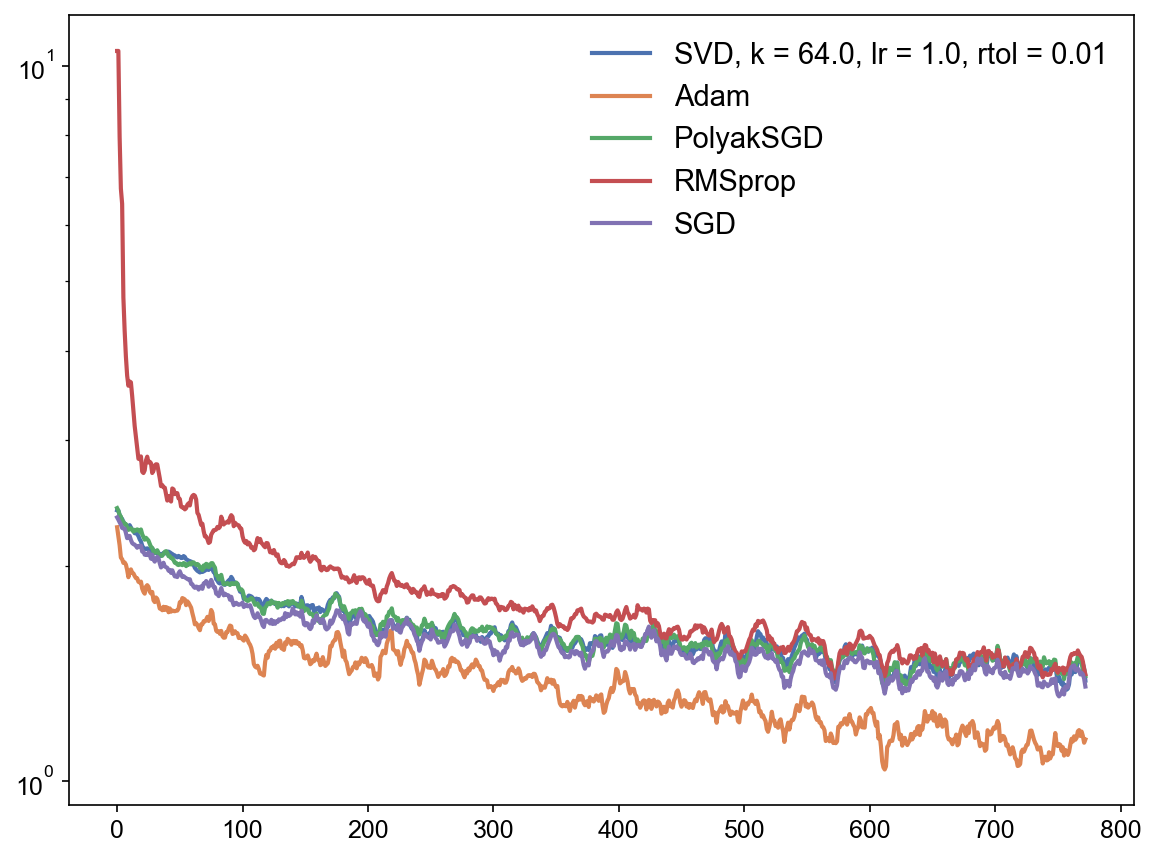

In [16]:
colors = sns.color_palette("deep")

fig, ax = plt.subplots(figsize=(8, 6))
legend_labels = []
n_smooth = 10

# Best SVD
for i, o in enumerate(['SVD'] + optimizers):
    opt_df = df[(df['optimizer'] == o) & (df['batch_size'] == bs)]
    best_row = df.loc[opt_df['final_val_loss'].idxmin()]
    losses = get_loss_curve(best_row, 'train_batch')
    smoothed = np.convolve(losses, np.ones(n_smooth)/n_smooth, mode='valid')
    label = o
    if o == 'SVD':
        label += f", k = {best_row['k']}, lr = {best_row['lr']}, rtol = {best_row['rtol']}"
    plt.plot(smoothed, label=label, color=colors[i])

plt.yscale('log')
plt.legend()
#plt.xlim([0,100])

plt.tight_layout()
#plt.savefig(PLOT_DIR / 'train_loss_best.pdf')
plt.show()

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

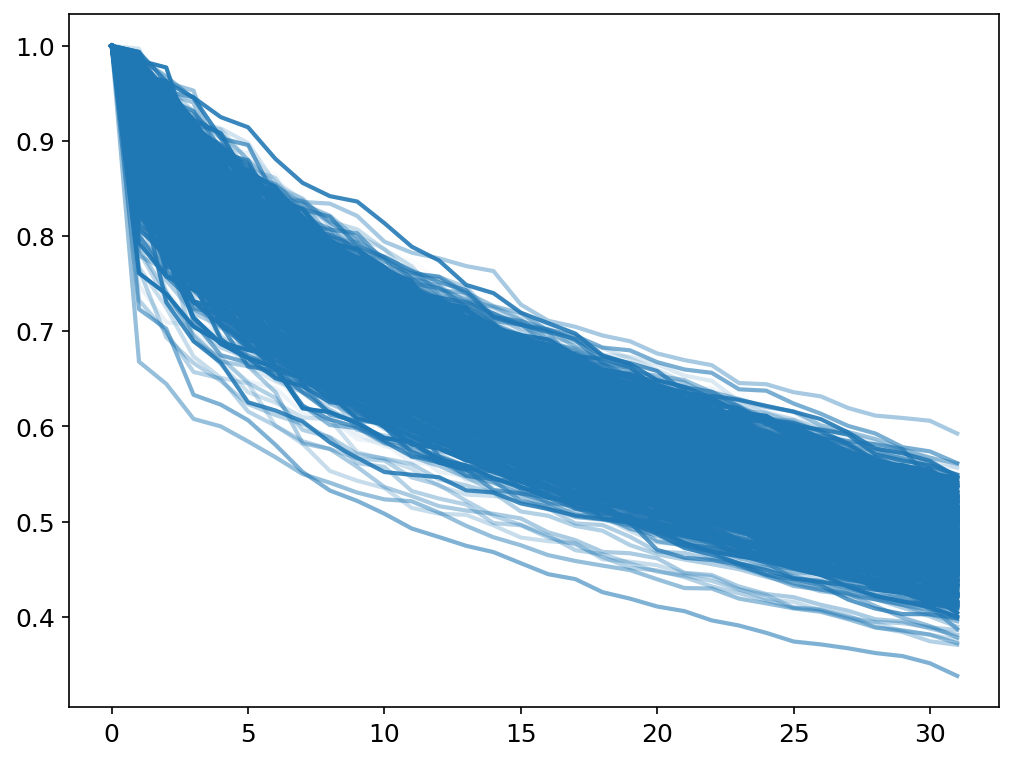

In [21]:
svd_info = df_sven['svd_info'].iloc[0]

plt.figure(figsize=(8,6))
N = len(svd_info['svs'])
for i,svs in enumerate(svd_info['svs']):
    s = np.array(svs)
    plt.plot(s/s[0],lw=2,alpha=(N-i)/N,color='C0')
